# 1. Load the clean data

In [65]:
import numpy as np
import pandas as pd
data_clean=pd.read_csv("cleaned_dataset.csv")
data_clean

,ViewYN,PoolPrivateYN,ClosePrice,Latitude,Longitude,LivingArea,MLSAreaMajor,CountyOrParish,ParkingTotal,PropertySubType,...,FireplaceYN_missing,PoolPrivateYN_missing,NewConstructionYN_missing,PropertyType_CommercialLease,PropertyType_CommercialSale,PropertyType_Land,PropertyType_ManufacturedInPark,PropertyType_Residential,PropertyType_ResidentialIncome,PropertyType_ResidentialLease
0,1,0,6500.0,33.475311,-117.708995,3870.0,MB - Monarch Beach,Orange,2.0,SingleFamilyResidence,...,0,0,0,False,False,False,False,False,False,True
1,1,0,1800000.0,33.899427,-117.977995,7740.0,83 - Fullerton,Orange,3.0,SingleFamilyResidence,...,0,0,0,False,False,False,False,True,False,False
2,1,0,1200000.0,34.095980,-118.221993,4697.0,680 - Mount Washington,Los Angeles,2.0,SingleFamilyResidence,...,0,0,0,False,False,False,False,True,False,False
3,1,1,3200.0,33.773119,-116.343788,1581.0,324 - East Palm Desert,Riverside,2.0,Condominium,...,0,0,0,False,False,False,False,False,False,True
4,1,0,1425000.0,33.884526,-117.778002,7500.0,85 - Yorba Linda,Orange,2.0,SingleFamilyResidence,...,0,0,0,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203272,1,0,865000.0,34.242304,-116.802871,868586.4,BBC - Big Bear City,San Bernardino,2.0,SingleFamilyResidence,...,0,0,0,False,False,False,False,True,False,False
203273,1,1,4000.0,33.701018,-116.292460,7405.0,313 - La Quinta South of HWY 111,Riverside,3.0,SingleFamilyResidence,...,0,0,0,False,False,False,False,False,False,True
203274,0,0,127500.0,34.251991,-116.820227,1440.0,BBC - Big Bear City,San Bernardino,2.0,Unknown,...,1,0,1,False,False,False,True,False,False,False
203275,0,0,595000.0,37.824500,-122.281570,4389.0,Unknown,Alameda,3.0,SingleFamilyResidence,...,0,0,0,False,False,False,False,True,False,False


# 2. Test train valid split

In [66]:
X=7 # past 6 month
months = sorted(data_clean["date_ym"].unique())
# data_train=data_clean[data_clean['date_ym'].isin(months[-X:-2])]
# data_valid=data_clean[data_clean['date_ym'].isin(months[-2:-1])]
# data_test=data_clean[data_clean['date_ym']==months[-1]]
data_train=data_clean[data_clean['date_ym'].isin(months[-X:-1])]
data_test=data_clean[data_clean['date_ym']==months[-1]]
print(data_train['date_ym'].value_counts())
print(data_test['date_ym'].value_counts())
data_train.info()

date_ym
2026-04-01    15568
2026-05-01    15553
2026-03-01    15000
2025-12-01    13394
2026-02-01    11812
2026-01-01    10701
Name: count, dtype: int64
date_ym
2026-06-01    16410
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 82028 entries, 104839 to 186866
Data columns (total 37 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   ViewYN                           82028 non-null  int64  
 1   PoolPrivateYN                    82028 non-null  int64  
 2   ClosePrice                       82028 non-null  float64
 3   Latitude                         82028 non-null  float64
 4   Longitude                        82028 non-null  float64
 5   LivingArea                       82028 non-null  float64
 6   MLSAreaMajor                     82028 non-null  object 
 7   CountyOrParish                   82028 non-null  object 
 8   ParkingTotal                     82028 non-null  float64


In [67]:
cols=["CountyOrParish","City","StateOrProvince","MLSAreaMajor","PropertySubType","Levels","PostalCode"]
for col in cols:
    top10 = data_train[col].value_counts().nlargest(10).index
    data_train[col] = data_train[col].where(data_train[col].isin(top10), "Other")
    data_test[col] = data_test[col].where(data_test[col].isin(top10), "Other")
data_train = pd.get_dummies(data_train, columns=cols, drop_first=True)
data_test = pd.get_dummies(data_test, columns=cols, drop_first=True)
# 保证列一致
data_test = data_test.reindex(columns=data_train.columns, fill_value=0)

C:\Users\23035\AppData\Local\Temp\ipykernel_53576\3121791956.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_train[col] = data_train[col].where(data_train[col].isin(top10), "Other")
C:\Users\23035\AppData\Local\Temp\ipykernel_53576\3121791956.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_test[col] = data_test[col].where(data_test[col].isin(top10), "Other")
C:\Users\23035\AppData\Local\Temp\ipykernel_53576\3121791956.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of 

In [68]:
data_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16410 entries, 186867 to 203276
Data columns (total 94 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   ViewYN                                             16410 non-null  int64  
 1   PoolPrivateYN                                      16410 non-null  int64  
 2   ClosePrice                                         16410 non-null  float64
 3   Latitude                                           16410 non-null  float64
 4   Longitude                                          16410 non-null  float64
 5   LivingArea                                         16410 non-null  float64
 6   ParkingTotal                                       16410 non-null  float64
 7   LotSizeAcres                                       16410 non-null  float64
 8   YearBuilt                                          16410 non-null  float64
 9   Stree

In [69]:
# remove some columns that related to the feature
X_train, y_train = data_train.drop(columns=["ClosePrice"] + data_train.select_dtypes(include=["object"]).columns.tolist()), data_train["ClosePrice"]
X_test, y_test = data_test.drop(columns=["ClosePrice"] + data_train.select_dtypes(include=["object"]).columns.tolist()), data_test["ClosePrice"]

In [70]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 82028 entries, 104839 to 186866
Data columns (total 92 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   ViewYN                                             82028 non-null  int64  
 1   PoolPrivateYN                                      82028 non-null  int64  
 2   Latitude                                           82028 non-null  float64
 3   Longitude                                          82028 non-null  float64
 4   LivingArea                                         82028 non-null  float64
 5   ParkingTotal                                       82028 non-null  float64
 6   LotSizeAcres                                       82028 non-null  float64
 7   YearBuilt                                          82028 non-null  float64
 8   StreetNumberNumeric                                82028 non-null  float64
 9   Bathr

# 3. Train a Linear Regression model and Evaluate the result

In [71]:
results = []

## 3.1 Ordinary Linear Regression 

In [72]:
#linear regression
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

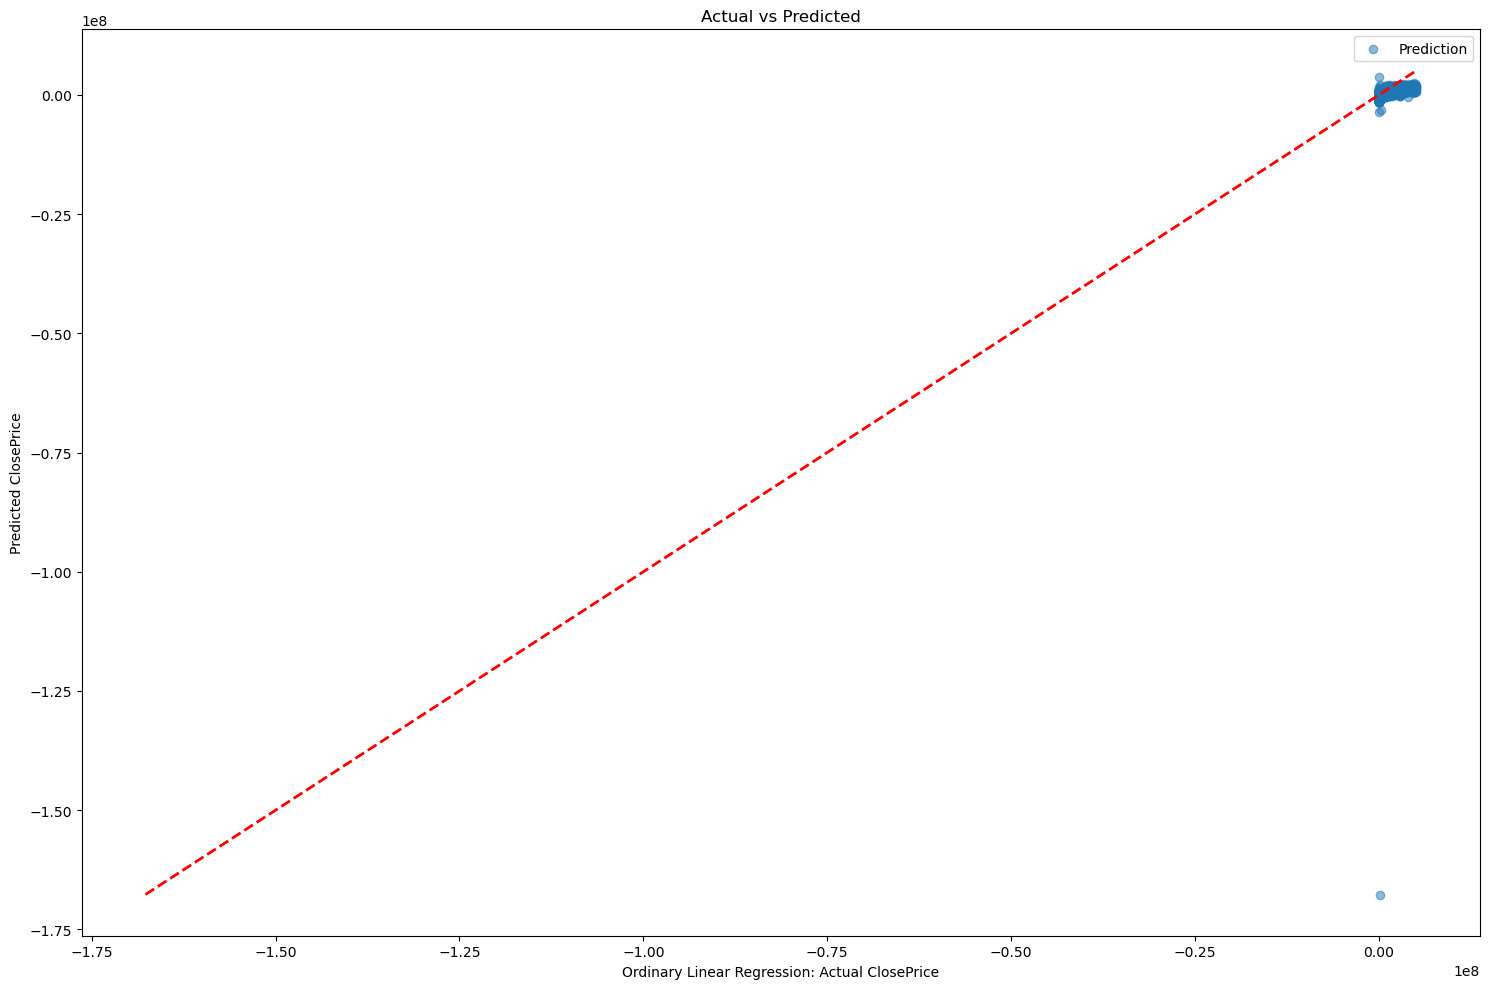

In [73]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
plt.scatter(y_test, y_pred, alpha=0.5, label="Prediction")

# y=x
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

plt.xlabel("Ordinary Linear Regression: Actual ClosePrice")
plt.ylabel("Predicted ClosePrice")
plt.title("Actual vs Predicted")
plt.tight_layout()
plt.legend()
plt.show()

In [74]:
# Median Absolute Percentage Error, MAPE,R2,MAE,MSE,RMSE

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred)
mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100

print(f"MdAPE: {mdape:.2f}%")
print(f"MAPE : {mape:.4f}")
print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")

results.append({
    "model":"Ordinary Linear Regression",
    "MdAPE":mdape,
    "MAPE":mape,
    "R2":r2,
    "MAE":mae,
    "MSE":mse,
    "RMSE":rmse
})

MdAPE: 64.98%
MAPE : 42.5914
R²   : -3.0230
MAE  : 582128.7680
MSE  : 2245524060609.9390
RMSE : 1498507.2775


## 3.2 Ridge Regression

In [75]:
from sklearn.linear_model import Ridge

model = Ridge(alpha=1.0)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

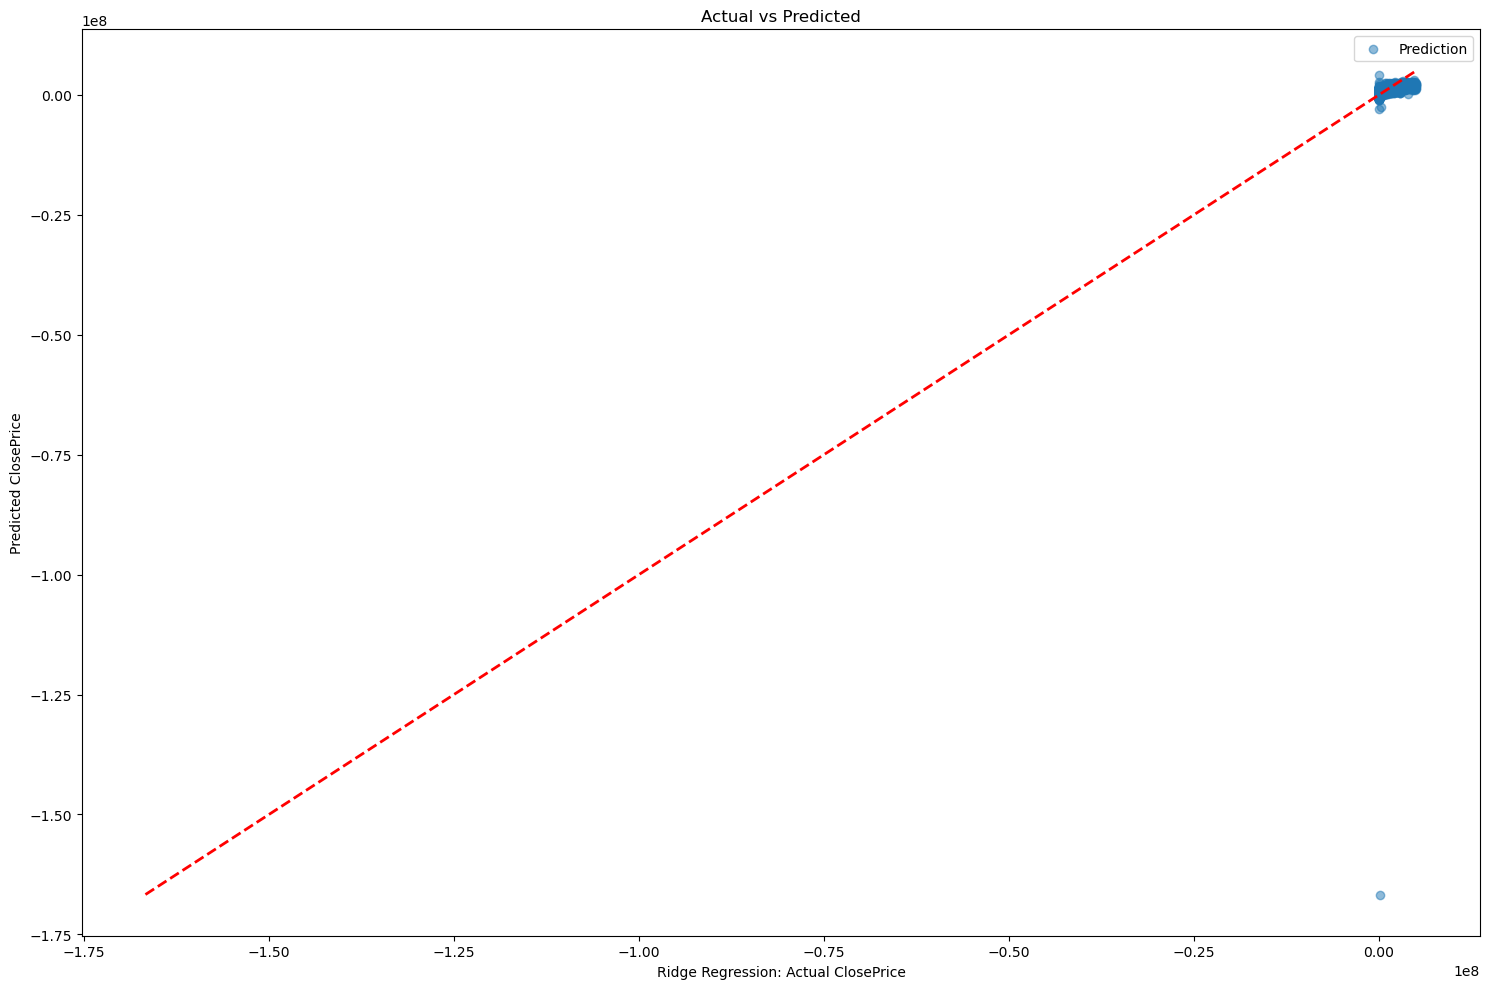

In [76]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
plt.scatter(y_test, y_pred, alpha=0.5, label="Prediction")

# 理想预测线 y=x
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

plt.xlabel("Ridge Regression: Actual ClosePrice")
plt.ylabel("Predicted ClosePrice")
plt.title("Actual vs Predicted")
plt.tight_layout()
plt.legend()
plt.show()

In [77]:
# Median Absolute Percentage Error, MAPE,R2,MAE,MSE,RMSE

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred)
mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100

print(f"MdAPE: {mdape:.2f}%")
print(f"MAPE : {mape:.4f}")
print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")

results.append({
    "model":"Ridge Regression",
    "MdAPE":mdape,
    "MAPE":mape,
    "R2":r2,
    "MAE":mae,
    "MSE":mse,
    "RMSE":rmse
})

MdAPE: 38.86%
MAPE : 16.8770
R²   : -2.4356
MAE  : 326998.1660
MSE  : 1917619491990.5874
RMSE : 1384781.3878


## 3.3 Lasso Regression

In [78]:
from sklearn.linear_model import Lasso

model = Lasso(alpha=0.1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

C:\Users\23035\.conda\envs\torch-gpu\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:648: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.815e+15, tolerance: 4.462e+12
  model = cd_fast.enet_coordinate_descent(


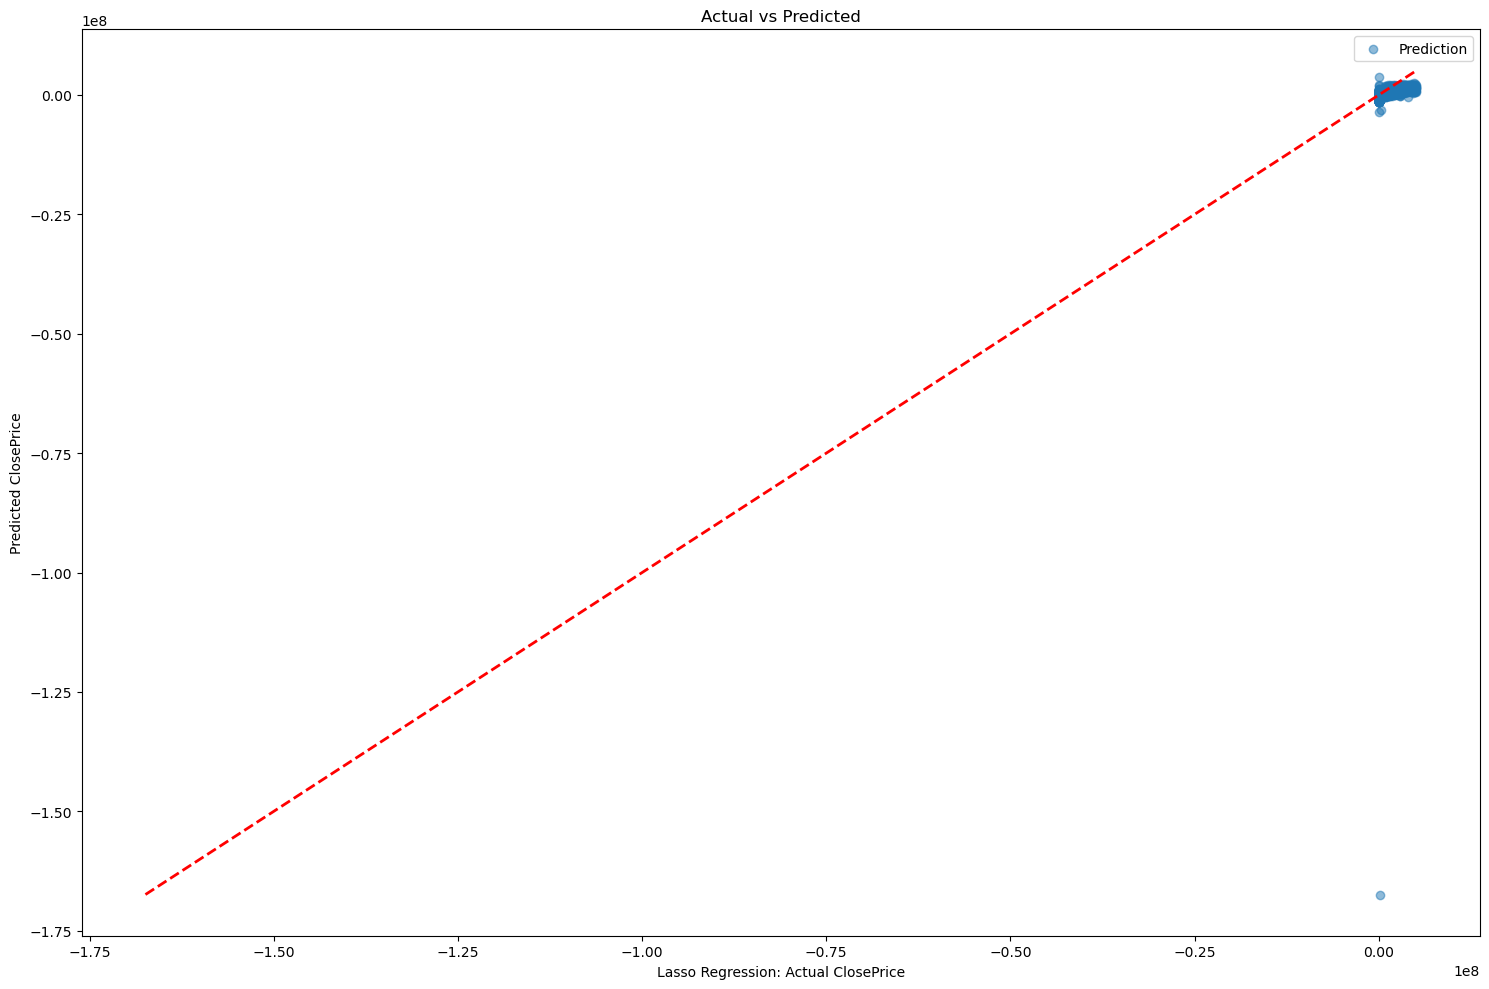

In [79]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
plt.scatter(y_test, y_pred, alpha=0.5, label="Prediction")

# 理想预测线 y=x
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

plt.xlabel("Lasso Regression: Actual ClosePrice")
plt.ylabel("Predicted ClosePrice")
plt.title("Actual vs Predicted")
plt.tight_layout()
plt.legend()
plt.show()

In [80]:
# Median Absolute Percentage Error, MAPE,R2,MAE,MSE,RMSE

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred)
mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100

print(f"MdAPE: {mdape:.2f}%")
print(f"MAPE : {mape:.4f}")
print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")

results.append({
    "model":"Lasso Regression",
    "MdAPE":mdape,
    "MAPE":mape,
    "R2":r2,
    "MAE":mae,
    "MSE":mse,
    "RMSE":rmse
})

MdAPE: 63.34%
MAPE : 41.6592
R²   : -2.9828
MAE  : 568069.1159
MSE  : 2223081747592.3140
RMSE : 1491000.2507


## 3.4 ElasticNet

In [81]:
from sklearn.linear_model import ElasticNet

model = ElasticNet(alpha=0.1, l1_ratio=0.5)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

C:\Users\23035\.conda\envs\torch-gpu\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:648: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.086e+16, tolerance: 4.462e+12
  model = cd_fast.enet_coordinate_descent(


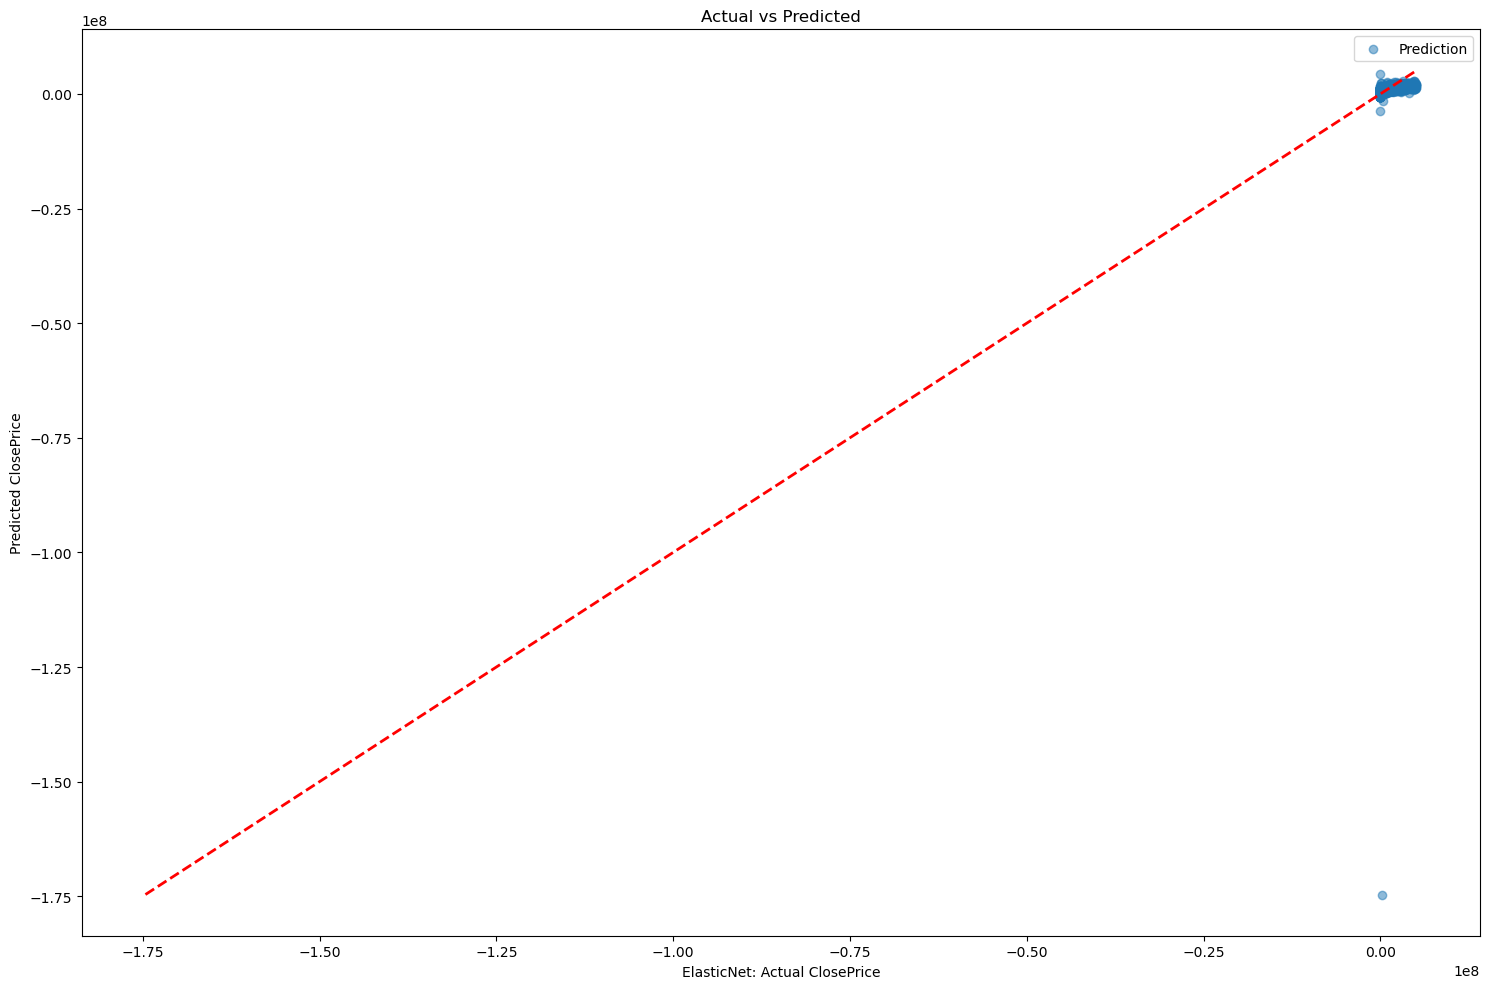

In [82]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
plt.scatter(y_test, y_pred, alpha=0.5, label="Prediction")

# 理想预测线 y=x
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

plt.xlabel("ElasticNet: Actual ClosePrice")
plt.ylabel("Predicted ClosePrice")
plt.title("Actual vs Predicted")
plt.tight_layout()
plt.legend()
plt.show()

In [83]:
# Median Absolute Percentage Error, MAPE,R2,MAE,MSE,RMSE

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred)
mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100

print(f"MdAPE: {mdape:.2f}%")
print(f"MAPE : {mape:.4f}")
print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")

results.append({
    "model":"ElasticNet",
    "MdAPE":mdape,
    "MAPE":mape,
    "R2":r2,
    "MAE":mae,
    "MSE":mse,
    "RMSE":rmse
})

MdAPE: 37.93%
MAPE : 16.0130
R²   : -2.7725
MAE  : 331324.0030
MSE  : 2105696958753.1301
RMSE : 1451101.9808


# 5. Rolling-Origin Backtesting

In [84]:
result_roll=[]

for X in range(4,12):
    months = sorted(data_clean["date_ym"].unique())
    data_train=data_clean[data_clean['date_ym'].isin(months[:X])]
    data_test=data_clean[data_clean['date_ym']==months[X]]
    cols=["CountyOrParish","City","StateOrProvince"]
    for col in cols:
       top10 = data_train[col].value_counts().nlargest(10).index
       data_train[col] = data_train[col].where(data_train[col].isin(top10), "Other")
       data_test[col] = data_test[col].where(data_test[col].isin(top10), "Other")
    data_train = pd.get_dummies(data_train, columns=cols, drop_first=True)
    data_test = pd.get_dummies(data_test, columns=cols, drop_first=True)
    # keep the cols consistently
    data_test = data_test.reindex(columns=data_train.columns, fill_value=0)
    X_train, y_train = data_train.drop(columns=["ClosePrice"] + data_train.select_dtypes(include=["object"]).columns.tolist()), data_train["ClosePrice"]
    X_test, y_test = data_test.drop(columns=["ClosePrice"] + data_train.select_dtypes(include=["object"]).columns.tolist()), data_test["ClosePrice"]

    # linear regression
    
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100
    print(f"------------------------------{X}----------------------------------")
    print("--------------Ordinary Linear regression-------------")
    print(f"MdAPE: {mdape:.2f}%")
    print(f"MAPE : {mape:.4f}")
    print(f"R²   : {r2:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    result_roll.append({
    "model":"Ordinary Linear Regression",
    "train-test-X":X,
    "MdAPE":mdape,
    "MAPE":mape,
    "R2":r2,
    "MAE":mae,
    "MSE":mse,
    "RMSE":rmse
    })

    model = Ridge(alpha=1.0)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100
    print("--------------Ridge regression-------------")
    print(f"MdAPE: {mdape:.2f}%")
    print(f"MAPE : {mape:.4f}")
    print(f"R²   : {r2:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    result_roll.append({
    "model":"Ridge Regression",
    "train-test-X":X,
    "MdAPE":mdape,
    "MAPE":mape,
    "R2":r2,
    "MAE":mae,
    "MSE":mse,
    "RMSE":rmse
    })
    
    model = Lasso(alpha=0.1)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100
    print("--------------Lasso regression-------------")
    print(f"MdAPE: {mdape:.2f}%")
    print(f"MAPE : {mape:.4f}")
    print(f"R²   : {r2:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    result_roll.append({
    "model":"Lasso Regression",
    "train-test-X":X,
    "MdAPE":mdape,
    "MAPE":mape,
    "R2":r2,
    "MAE":mae,
    "MSE":mse,
    "RMSE":rmse
    })

    model = ElasticNet(alpha=0.1, l1_ratio=0.5)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100
    print("--------------ElasticNet regression-------------")
    print(f"MdAPE: {mdape:.2f}%")
    print(f"MAPE : {mape:.4f}")
    print(f"R²   : {r2:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    result_roll.append({
    "model":"ElasticNet",
    "train-test-X":X,
    "MdAPE":mdape,
    "MAPE":mape,
    "R2":r2,
    "MAE":mae,
    "MSE":mse,
    "RMSE":rmse
    })

    

------------------------------4----------------------------------
--------------Ordinary Linear regression-------------
MdAPE: 271.05%
MAPE : 97.1605
R²   : -4.0747
MAE  : 1576820.3869
MSE  : 2641635741155.6660
RMSE : 1625310.9675


C:\Users\23035\AppData\Local\Temp\ipykernel_53576\1494619583.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_train[col] = data_train[col].where(data_train[col].isin(top10), "Other")
C:\Users\23035\AppData\Local\Temp\ipykernel_53576\1494619583.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_test[col] = data_test[col].where(data_test[col].isin(top10), "Other")
C:\Users\23035\AppData\Local\Temp\ipykernel_53576\1494619583.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy 

--------------Ridge regression-------------
MdAPE: 125.12%
MAPE : 33.9385
R²   : -0.1466
MAE  : 695783.7537
MSE  : 596869828337.3022
RMSE : 772573.5100


C:\Users\23035\.conda\envs\torch-gpu\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:648: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.682e+15, tolerance: 3.266e+12
  model = cd_fast.enet_coordinate_descent(


--------------Lasso regression-------------
MdAPE: 266.23%
MAPE : 95.0407
R²   : -3.8908
MAE  : 1546676.1040
MSE  : 2545888640606.7007
RMSE : 1595584.1064


...

C:\Users\23035\.conda\envs\torch-gpu\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:648: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.829e+16, tolerance: 7.391e+12
  model = cd_fast.enet_coordinate_descent(
C:\Users\23035\AppData\Local\Temp\ipykernel_53576\1494619583.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_train[col] = data_train[col].where(data_train[col].isin(top10), "Other")
C:\Users\23035\AppData\Local\Temp\ipykernel_53576\1494619583.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] 

--------------ElasticNet regression-------------
MdAPE: 40.62%
MAPE : 16.9635
R²   : 0.5567
MAE  : 321059.4297
MSE  : 240696041172.5963
RMSE : 490607.8283
------------------------------11----------------------------------
--------------Ordinary Linear regression-------------
MdAPE: 38.29%
MAPE : 20.2637
R²   : 0.5683
MAE  : 321598.5621
MSE  : 246050836466.6512
RMSE : 496035.1162
--------------Ridge regression-------------
MdAPE: 38.27%
MAPE : 20.2700
R²   : 0.5687
MAE  : 321535.9319
MSE  : 245851069199.8313
RMSE : 495833.7112


C:\Users\23035\.conda\envs\torch-gpu\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:648: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.705e+16, tolerance: 8.205e+12
  model = cd_fast.enet_coordinate_descent(


--------------Lasso regression-------------
MdAPE: 38.29%
MAPE : 20.2613
R²   : 0.5684
MAE  : 321586.0696
MSE  : 246015880133.4054
RMSE : 495999.8792
--------------ElasticNet regression-------------
MdAPE: 39.36%
MAPE : 17.6352
R²   : 0.5376
MAE  : 328339.1113
MSE  : 263532788064.5851
RMSE : 513354.4468


C:\Users\23035\.conda\envs\torch-gpu\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:648: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.030e+16, tolerance: 8.205e+12
  model = cd_fast.enet_coordinate_descent(


# 6. Record results

In [85]:
import pandas as pd

result = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

result.to_csv("prediction_result.csv", index=True)
pd.DataFrame(results).to_csv("model_result.csv",index=True)
pd.DataFrame(result_roll).to_csv("model_result_roll.csv",index=True)